# Pre-processing

Set PATH for package imports.

In [1]:
import os
import sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root added to sys.path


Processing `npt-HK4.gro` file into pandas dataframe.

In [2]:
from utils import gro_processing as gp

# Data directory can be accessed due to root PATH we set previously
path = 'data/npt-HK4.gro'
abs_path = os.path.join(project_root, path)

# Extracts data from .gro file into multi-index DataFrame (unsorted)
df_gro, title, num_atoms, box_dimensions = gp.read_gro(abs_path, multiply=10, positions=True, velocities=False) # convert nm to Å  
    
# Checking
# df_gro

# Generating Molecule Meshes

Create `mol_meshes` dictionary, which contains 1501 individual molecule mesh, i.e. `{1: mesh1, 2: mesh2, ... 1501: mesh1501}`.

In [ ]:
from utils.generate_mol_meshes import molecules_to_meshes

mol_meshes = molecules_to_meshes(df_gro, box_dimensions, 
                                 sphere_radius_scale=0.8, 
                                 sphere_subdiv=2, 
                                 bond_radius=0.1,
                                 num_processes=None, 
                                 context='spawn') # 'spawn' for Windows, 'fork' for Linux/Mac
print(len(mol_meshes))        # 1501
print(mol_meshes[1])          # trimesh.Trimesh object

Processing 1501 molecules with 8 logical cores: 100%|██████████| 1501/1501 [01:26<00:00, 17.26it/s]


1501
<trimesh.Trimesh(vertices.shape=(18308, 3), faces.shape=(35904, 3))>


## Export meshes

Users can export meshes as `.npz` or `.ply` file.
- `.npz` is much smaller $\sim400\,\mathrm{MB}$, but exports longer $\sim50\,\mathrm{s}$
- `.ply` file is larger $\sim1.00\,\mathrm{GB}$, but exports shorter $\sim20\,\mathrm{s}$

In [ ]:
from utils.generate_mol_meshes import export_meshes

# Export to either npz file or ply directory
# export_meshes(mol_meshes, path=path, export_format='npz', num_processes=None, context='fork')
export_meshes(mol_meshes, path=path, export_format='ply', num_processes=None, context='spawn')

Exporting 1501 meshes with 8 logical cores: 100%|██████████| 1501/1501 [00:15<00:00, 99.93it/s] 


Successfully saved all meshes into directory: npt-HK4_meshes
File size: 1087.88 MB


# Import meshes

Users can import meshes from `.npz` or `.ply` file.
- `.npz` longer import $\sim20\,\mathrm{s}$ (parallel does not work well here) 
- `.ply` shorter import $\sim8\,\mathrm{s}$

In [3]:
from utils.generate_mol_meshes import import_meshes

# Import either npz files or ply directory (auto-detect)
# mol_meshes = import_meshes(path='npt-HK4_meshes.npz', num_processes=None, context='fork')
mol_meshes = import_meshes(path='npt-HK4_meshes', num_processes=None, context='spawn')

Loading 1501 meshes with 8 cores: 100%|██████████| 1501/1501 [00:11<00:00, 129.48it/s]


# Generate neighbors pairs (Blocking Algo)

All the functions have been merged into main function `find_neighbors`. User can export to CSV, data that are exported include:
- centroids
- e-centroids
- neighbor_candidates
- neighbor_pairs

This function is designed to accommodate incomplete `mol_meshes` data. For example, if the following meshes are missing: `mol_id=[2,3,5]`, the output will simply exclude them (e.g., `mol_meshes = {1:trimesh,3:trimesh,6:trimesh,...,1501:trimesh}`). Consequently, the blocking algorithm continues uninterrupted using only the available meshes.

In [11]:
from utils.blocking_algo import find_neighbor_pairs

neighbor_pairs, e_centroids, centroids, neighbor_candidates = find_neighbor_pairs(mol_meshes, df_gro, box_dimensions, path, k=10, export_csv=True)

# print(e_centroids)
# print(centroids)
# print("Neighbor candidates:",len(neighbor_candidates))
# print("Neighbor pairs:", len(neighbor_pairs))

Insert atom id for one molecule.
Use the following format: '20-30; 30; 20; 40-60' (for range use '-', for multi-input split using ';' 
----------------------------------------
You entered: [32-53]
----------------------------------------
Selected atom_id(s): [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53]


Testing neighbor pairs: 100%|██████████| 2206/2206 [01:28<00:00, 25.03it/s] 


----------------------------------------
Successfully exported npt-HK4_e_centroids.csv
Successfully exported npt-HK4_centroids.csv
Successfully exported npt-HK4_neighbor_candidates.csv
Exported npt-HK4_neighbor_pairs.csv


# Import neighbor pairs

Because finding `neighbor_pairs` is heavy.

In [5]:
from utils.blocking_algo import import_csv

e_centroids = import_csv('./npt-HK4_e_centroids.csv')
centroids = import_csv('./npt-HK4_centroids.csv')
neighbor_candidates = import_csv('./npt-HK4_neighbor_candidates.csv')
neighbor_pairs = import_csv('./npt-HK4_neighbor_pairs.csv')
# fail_1 = import_csv('./npt-HK4_fail_1.csv')  # Should raise error

# print('-' * 40)
# print(f'{e_centroids=}')
# print(f'{centroids=}')
# print(f'{neighbor_pairs=}')
# print(f'{neighbor_candidates=}')

Successfully imported centroids CSV file: './npt-HK4_e_centroids.csv'.
Successfully imported centroids CSV file: './npt-HK4_centroids.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_candidates.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_pairs.csv'.


# Results

Calculate MIC distances of every single `neighbor_candidates` and plots them in a histogram.

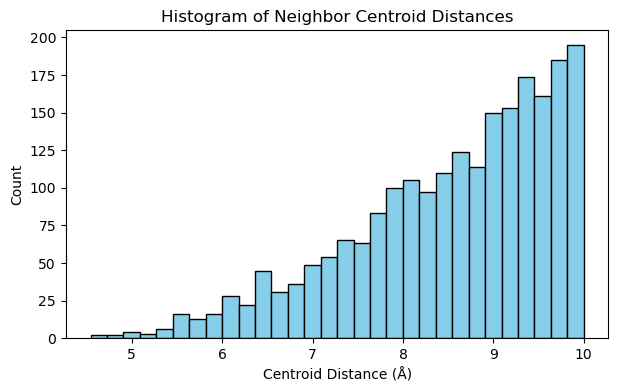

In [9]:
import matplotlib.pyplot as plt
import utils.mic_helper as mh

# Calculate and store distances between neighbor candidate pairs using centroids
neighbor_distances = {}
for i, j in neighbor_candidates:
    c_i = centroids[i]
    c_j = centroids[j]
    dist = mh.mic_distance(c_i, c_j, box_dimensions)
    neighbor_distances[(i, j)] = dist

# Get the list of distances
distances = list(neighbor_distances.values())

plt.figure(figsize=(7,4))
plt.hist(distances, bins=30, color='skyblue', edgecolor='k')
plt.xlabel('Centroid Distance (Å)')
plt.ylabel('Count')
plt.title('Histogram of Neighbor Centroid Distances')
plt.show()

# Verify blocking molecules

Immediately creates a `pyglet` window for users to visually verify blocking molecules.

In [12]:
from utils.blocking_algo import view_molecule

# 107, 491, 530
mol_id = 107 # molecule ID to visualize
view_molecule(mol_id, e_centroids, mol_meshes, neighbor_candidates, neighbor_pairs, 
              view_unpaired_mols=True, distinct_color=True, alpha=100)

Neighbor pairs for molecule 107: [197, 945, 1305]
Non-paired neighbors are: [330]
----------------------------------------
You have selected: [330]
----------------------------------------
You are now viewing molecules [107, 197, 330, 945, 1305]


SceneViewer(width=1920, height=1043)

Generate 3D graph network and histogram of number of pairs per molecule

The pairs without e_coupling has been exported to: npt-HK4_pairs_without_e_coupling.txt


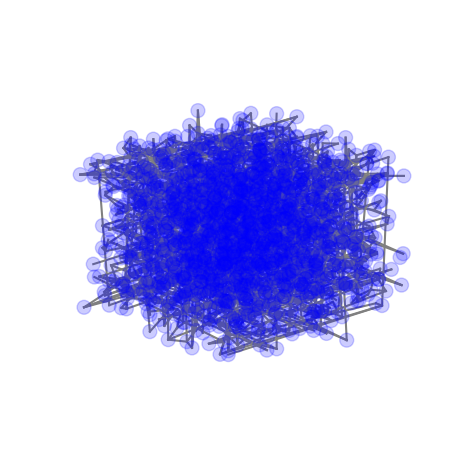

Average pairs per molecule: 2.732844770153231


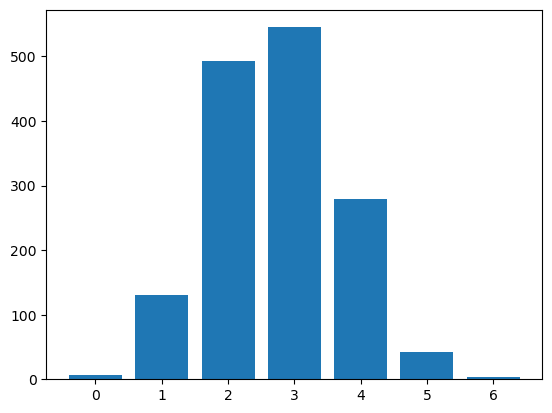

In [13]:
from utils import networkx_graph_making as ngm

# User must input centroids csv, neighbor pairs csv and e_coupling data txt file, sample of format of txt file can be found under data/e-coupling_with_nn_distance.txt
G = ngm.networkx_graph_making(centroids_path = "npt-HK4_centroids.csv",
                          neighbor_pairs_path = "npt-HK4_neighbor_pairs.csv",
                          e_coupling_data_path = "../../data/e-coupling_with_nn_distance.txt",
                          pairs_without_e_coupling_to_txt = True,  # Set to True to export to txt file
                          plot_3D_to_gif = True                     # Set to True to produce gif of graph
                          )

ngm.average_pairs_per_molecule(G) # Input graph object generated from the above object to get average pairs per molecule

## Verify the validity of choosing the threshold distance equal 10Å

In [14]:
from utils.blocking_algo import get_neighbor_candidates

# List of nearest neighbor pairs
nearest_neighbors = get_neighbor_candidates(box_dimensions, centroids, k=1, threshold_distance=30)
print("Nearest neighbor pairs:", len(nearest_neighbors))

Nearest neighbor pairs: 741


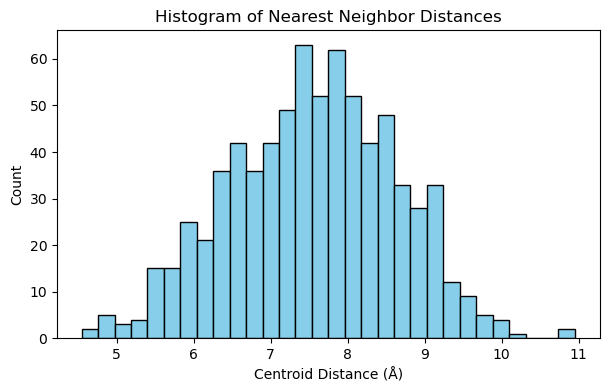

In [15]:
# Calculate and store distances between nearest neighbors pairs using centroids
neighbor_distances = {}
for i, j in nearest_neighbors:
    c_i = centroids[i]
    c_j = centroids[j]
    dist = mh.mic_distance(c_i, c_j, box_dimensions)
    neighbor_distances[(i, j)] = dist

# Get the list of distances
distances = list(neighbor_distances.values())

plt.figure(figsize=(7,4))
plt.hist(distances, bins=30, color='skyblue', edgecolor='k')
plt.xlabel('Centroid Distance (Å)')
plt.ylabel('Count')
plt.title('Histogram of Nearest Neighbor Distances')
plt.show()